# ResNet50 + SimCLRv2 Linear Eval — Memory Safe

Notebook này sửa lỗi OOM bằng cách:

1. Load checkpoint pretrain.
2. Freeze backbone.
3. Extract feature bằng `torch.no_grad()`.
4. Train linear classifier trên feature đã cache.

Như vậy GPU chỉ dùng để forward backbone và train classifier nhỏ, nhẹ hơn nhiều so với chạy linear eval kiểu forward full model + backward.


In [1]:
from pathlib import Path
import sys, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Torch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Config


In [2]:
PROJECT_DIR = Path(r"D:\ML3")
DATA_ROOT = PROJECT_DIR / "data"
PRETRAIN_CKPT = PROJECT_DIR / "checkpoints_2" / "simclrv2_resnet50_epoch_300.pt"

OUT_ROOT = PROJECT_DIR / "paper_outputs" / "linear_eval_memorysafe"
FIG_DIR = OUT_ROOT / "figures"
TABLE_DIR = OUT_ROOT / "tables"
CKPT_DIR = OUT_ROOT / "checkpoints_2"

for d in [OUT_ROOT, FIG_DIR, TABLE_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

FEATURE_BATCH_SIZE = 64     # nếu vẫn OOM khi extract feature, hạ xuống 32 hoặc 16
LINEAR_BATCH_SIZE = 256     # train classifier trên feature, nhẹ
EPOCHS = 100
LR = 0.1
WEIGHT_DECAY = 0.0
MOMENTUM = 0.9

assert PROJECT_DIR.exists(), PROJECT_DIR
assert DATA_ROOT.exists(), DATA_ROOT
assert PRETRAIN_CKPT.exists(), PRETRAIN_CKPT

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_ROOT:", DATA_ROOT)
print("PRETRAIN_CKPT:", PRETRAIN_CKPT)
print("DEVICE:", DEVICE)


PROJECT_DIR: D:\ML3
DATA_ROOT: D:\ML3\data
PRETRAIN_CKPT: D:\ML3\checkpoints_2\simclrv2_resnet50_epoch_300.pt
DEVICE: cuda


## 2. Setup


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

def save_fig(name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)

def confusion_matrix_np(y_true, y_pred, n):
    cm = np.zeros((n, n), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm


## 3. Import project code


In [4]:
sys.path.insert(0, str(PROJECT_DIR))

from resnet18 import build_resnet
from ssl_simclr import SimCLR
from dataset import get_dataloaders

print("Project imports OK")


Project imports OK


## 4. Load pretrained backbone


In [5]:
ckpt = torch.load(PRETRAIN_CKPT, map_location="cpu")
args = ckpt.get("args", {})

ARCH = args.get("arch", "resnet50")
NUM_CLASSES = int(args.get("num_classes", 10))
IMAGE_SIZE = int(args.get("image_size", 96))
PROJ_DIM = int(args.get("proj_dim", 128))
PROJ_LAYERS = int(args.get("proj_layers", 3))
PROJ_HIDDEN_DIM_ARG = int(args.get("proj_hidden_dim", 0) or 0)

print("ckpt epoch:", ckpt.get("epoch"))
print("mode:", ckpt.get("mode"))
print("arch:", ARCH)
print("image_size:", IMAGE_SIZE)

backbone = build_resnet(ARCH, num_classes=NUM_CLASSES)
feat_dim = getattr(backbone, "feature_dim", 512)

simclr = SimCLR(
    backbone=backbone,
    feat_dim=feat_dim,
    proj_dim=PROJ_DIM,
    proj_hidden_dim=PROJ_HIDDEN_DIM_ARG or feat_dim,
    proj_layers=PROJ_LAYERS,
)

state = ckpt["model"]
state = {k.replace("module.", "", 1): v for k, v in state.items()}
msg = simclr.load_state_dict(state, strict=False)
print("missing:", len(msg.missing_keys), msg.missing_keys[:10])
print("unexpected:", len(msg.unexpected_keys), msg.unexpected_keys[:10])

backbone = simclr.backbone
backbone.fc = nn.Identity()
backbone = backbone.to(DEVICE).eval()

for p in backbone.parameters():
    p.requires_grad = False

print("feature dim:", feat_dim)


C:\Users\DELL\AppData\Local\Temp\ipykernel_7472\253964865.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(PRETRAIN_CKPT, map_location="cpu")


ckpt epoch: 300
mode: pretrain
arch: resnet50
image_size: 96
missing: 2 ['backbone.fc.weight', 'backbone.fc.bias']
unexpected: 0 []
feature dim: 2048


## 5. Dataloaders


In [6]:
train_loader, val_loader = get_dataloaders(
    batch_size=FEATURE_BATCH_SIZE,
    data_root=str(DATA_ROOT),
    dataset="stl10",
    image_size=IMAGE_SIZE,
    num_workers=0,
    download=False,
    use_cuda=(DEVICE.type == "cuda"),
    distributed=False,
)

class_names = getattr(val_loader.dataset, "classes", [str(i) for i in range(NUM_CLASSES)])

print("train samples:", len(train_loader.dataset))
print("val samples:", len(val_loader.dataset))
print("classes:", class_names)


train samples: 5000
val samples: 8000
classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


## 6. Extract cached features


In [7]:
@torch.no_grad()
def extract_features(backbone, loader, device):
    feats, labels = [], []
    t0 = time.time()
    backbone.eval()

    for i, (x, y) in enumerate(loader, start=1):
        x = x.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            f = backbone(x)

        feats.append(f.detach().cpu().float())
        labels.append(y.detach().cpu().long())

        if i % 20 == 0 or i == len(loader):
            print(f"extract {i}/{len(loader)}")

    feats = torch.cat(feats, dim=0)
    labels = torch.cat(labels, dim=0)
    print("features:", tuple(feats.shape), "labels:", tuple(labels.shape), "time:", round(time.time() - t0, 1), "s")
    return feats, labels

cache_dir = OUT_ROOT / "feature_cache"
cache_dir.mkdir(exist_ok=True)
train_feat_path = cache_dir / "train_features.pt"
val_feat_path = cache_dir / "val_features.pt"

if train_feat_path.exists() and val_feat_path.exists():
    print("Loading cached features...")
    train_pack = torch.load(train_feat_path, map_location="cpu")
    val_pack = torch.load(val_feat_path, map_location="cpu")
    X_train, y_train = train_pack["features"], train_pack["labels"]
    X_val, y_val = val_pack["features"], val_pack["labels"]
else:
    print("Extracting train features...")
    X_train, y_train = extract_features(backbone, train_loader, DEVICE)
    torch.save({"features": X_train, "labels": y_train}, train_feat_path)

    print("Extracting val features...")
    X_val, y_val = extract_features(backbone, val_loader, DEVICE)
    torch.save({"features": X_val, "labels": y_val}, val_feat_path)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)

# giải phóng VRAM
backbone = backbone.cpu()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loading cached features...
X_train: torch.Size([5000, 2048]) y_train: torch.Size([5000])
X_val: torch.Size([8000, 2048]) y_val: torch.Size([8000])


C:\Users\DELL\AppData\Local\Temp\ipykernel_7472\2250763804.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_pack = torch.load(train_feat_path, map_location="cpu")


## 7. Linear classifier training


In [8]:
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)

train_feat_loader = DataLoader(train_ds, batch_size=LINEAR_BATCH_SIZE, shuffle=True)
val_feat_loader = DataLoader(val_ds, batch_size=LINEAR_BATCH_SIZE, shuffle=False)

clf = nn.Linear(X_train.shape[1], NUM_CLASSES).to(DEVICE)

optimizer = optim.SGD(clf.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
ce = nn.CrossEntropyLoss()

def eval_classifier(clf, loader, device):
    clf.eval()
    total_loss, correct, total = 0.0, 0, 0
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = clf(x)
            loss = ce(logits, y)
            prob = torch.softmax(logits, dim=1)
            pred = logits.argmax(dim=1)

            bs = y.numel()
            total += bs
            total_loss += float(loss.item()) * bs
            correct += int((pred == y).sum().item())

            y_true.append(y.cpu())
            y_pred.append(pred.cpu())
            y_prob.append(prob.cpu())

    return {
        "loss": total_loss / max(total, 1),
        "acc": 100.0 * correct / max(total, 1),
        "correct": correct,
        "total": total,
        "y_true": torch.cat(y_true).numpy(),
        "y_pred": torch.cat(y_pred).numpy(),
        "y_prob": torch.cat(y_prob).numpy(),
    }

history = []
best_acc = -1
best_path = CKPT_DIR / "linear_eval_best.pt"

for epoch in range(1, EPOCHS + 1):
    clf.train()
    t0 = time.time()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in train_feat_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = clf(x)
        loss = ce(logits, y)
        loss.backward()
        optimizer.step()

        bs = y.numel()
        total += bs
        total_loss += float(loss.item()) * bs
        correct += int((logits.argmax(1) == y).sum().item())

    train_loss = total_loss / total
    train_acc = 100.0 * correct / total
    val_res = eval_classifier(clf, val_feat_loader, DEVICE)
    lr_now = optimizer.param_groups[0]["lr"]
    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_res["loss"],
        "val_acc": val_res["acc"],
        "lr": lr_now,
        "time_sec": time.time() - t0,
    }
    history.append(row)

    print(
        f"epoch {epoch:03d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
        f"val_loss={val_res['loss']:.4f} val_acc={val_res['acc']:.2f}% | "
        f"lr={lr_now:.5g}"
    )

    if val_res["acc"] > best_acc:
        best_acc = val_res["acc"]
        torch.save({
            "epoch": epoch,
            "classifier": clf.state_dict(),
            "best_acc": best_acc,
            "args": {
                "mode": "linear-eval-memorysafe",
                "arch": ARCH,
                "feature_dim": X_train.shape[1],
                "num_classes": NUM_CLASSES,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "pretrain_ckpt": str(PRETRAIN_CKPT),
            },
        }, best_path)

df_history = pd.DataFrame(history)
df_history.to_csv(TABLE_DIR / "linear_eval_history.csv", index=False)
print("best_acc:", best_acc)
print("best_path:", best_path)


epoch 001/100 | train_loss=4.5602 train_acc=54.72% | val_loss=2.4428 val_acc=77.16% | lr=0.1
epoch 002/100 | train_loss=1.8993 train_acc=81.00% | val_loss=1.5384 val_acc=82.05% | lr=0.099975
epoch 003/100 | train_loss=1.1361 train_acc=84.66% | val_loss=1.1779 val_acc=83.19% | lr=0.099901
epoch 004/100 | train_loss=0.7316 train_acc=87.10% | val_loss=1.1191 val_acc=81.72% | lr=0.099778
epoch 005/100 | train_loss=0.5874 train_acc=87.26% | val_loss=0.9718 val_acc=82.40% | lr=0.099606
epoch 006/100 | train_loss=0.4677 train_acc=88.40% | val_loss=0.7809 val_acc=84.14% | lr=0.099384
epoch 007/100 | train_loss=0.2917 train_acc=91.48% | val_loss=0.7956 val_acc=83.16% | lr=0.099114
epoch 008/100 | train_loss=0.2270 train_acc=93.10% | val_loss=0.7178 val_acc=83.39% | lr=0.098796
epoch 009/100 | train_loss=0.1887 train_acc=93.78% | val_loss=0.7039 val_acc=83.55% | lr=0.098429
epoch 010/100 | train_loss=0.1532 train_acc=94.92% | val_loss=0.7249 val_acc=83.38% | lr=0.098015
epoch 011/100 | train_los

## 8. Curves


Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_loss.png
Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_loss.pdf


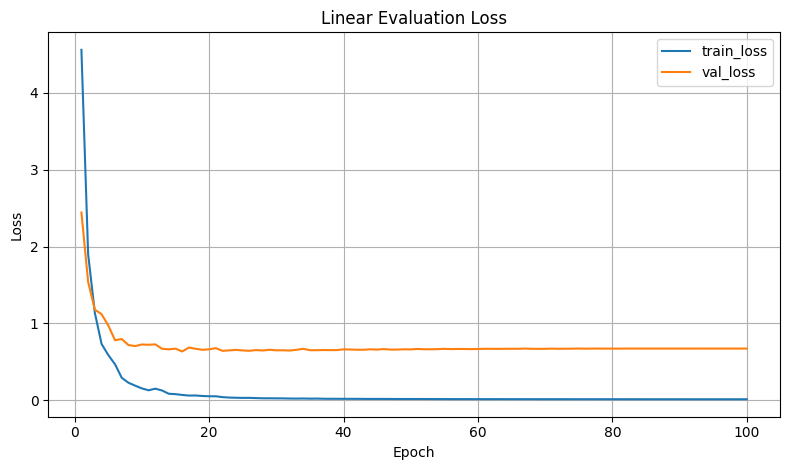

Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_accuracy.png
Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_accuracy.pdf


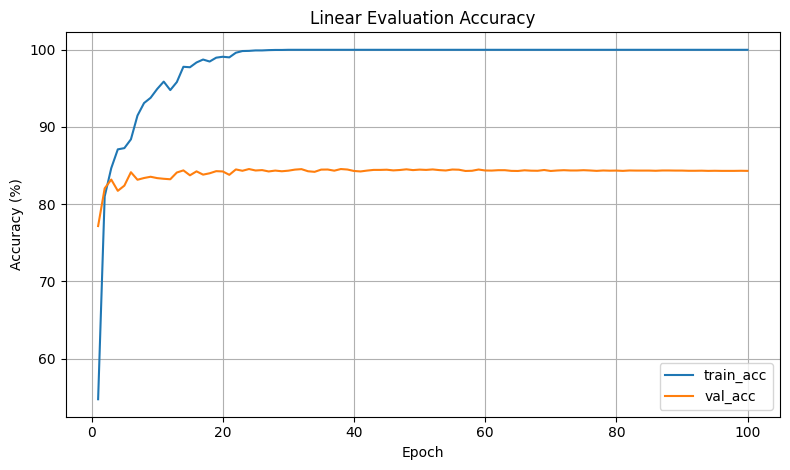

Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_lr.png
Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_lr.pdf


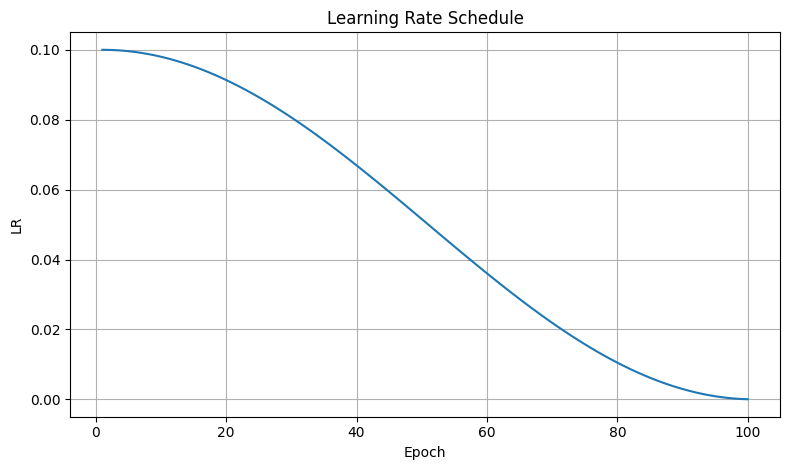

In [9]:
plt.figure(figsize=(8, 4.8))
plt.plot(df_history["epoch"], df_history["train_loss"], label="train_loss")
plt.plot(df_history["epoch"], df_history["val_loss"], label="val_loss")
plt.title("Linear Evaluation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_fig("linear_eval_loss")
plt.show()

plt.figure(figsize=(8, 4.8))
plt.plot(df_history["epoch"], df_history["train_acc"], label="train_acc")
plt.plot(df_history["epoch"], df_history["val_acc"], label="val_acc")
plt.title("Linear Evaluation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_fig("linear_eval_accuracy")
plt.show()

plt.figure(figsize=(8, 4.8))
plt.plot(df_history["epoch"], df_history["lr"])
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.tight_layout()
save_fig("linear_eval_lr")
plt.show()


## 9. Best model evaluation


In [10]:
best_payload = torch.load(best_path, map_location="cpu")
clf.load_state_dict(best_payload["classifier"], strict=True)
clf = clf.to(DEVICE).eval()

best_eval = eval_classifier(clf, val_feat_loader, DEVICE)

print("BEST_VAL_ACC:", f'{best_eval["acc"]:.2f}%')
print("VAL_LOSS:", round(best_eval["loss"], 4))
print("CORRECT:", f'{best_eval["correct"]}/{best_eval["total"]}')
print("BEST_EPOCH:", best_payload["epoch"])


C:\Users\DELL\AppData\Local\Temp\ipykernel_7472\3628125499.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_payload = torch.load(best_path, map_location="cpu")


BEST_VAL_ACC: 84.55%
VAL_LOSS: 0.6547
CORRECT: 6764/8000
BEST_EPOCH: 24


## 10. Confusion matrix and per-class accuracy


Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_confusion_matrix.png
Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_confusion_matrix.pdf


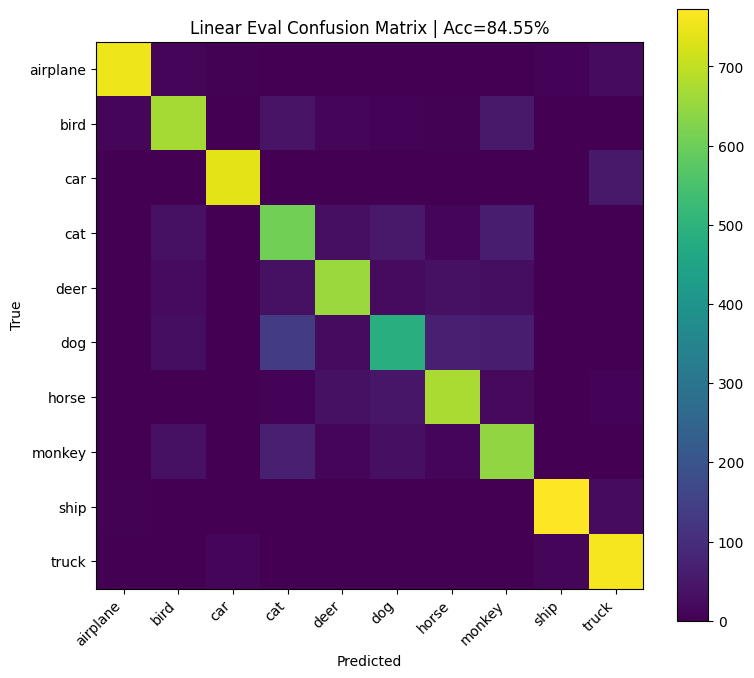

Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_confusion_matrix_normalized.png
Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_confusion_matrix_normalized.pdf


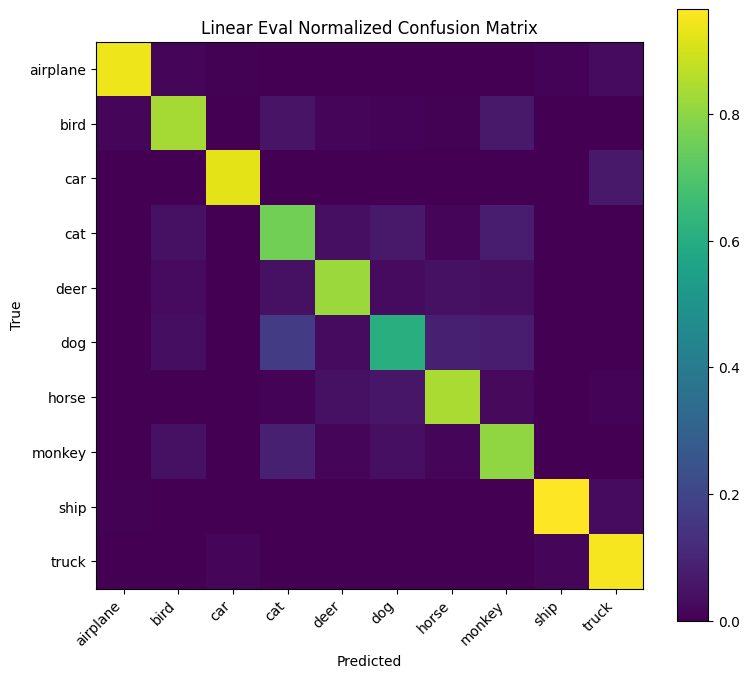

,class,correct,total,accuracy
8,ship,772,800,0.96500
9,truck,761,800,0.95125
0,airplane,753,800,0.94125
2,car,740,800,0.92500
6,horse,673,800,0.84125
1,bird,669,800,0.83625
4,deer,655,800,0.81875
7,monkey,645,800,0.80625
3,cat,609,800,0.76125
5,dog,487,800,0.60875


Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_per_class_accuracy.png
Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_per_class_accuracy.pdf


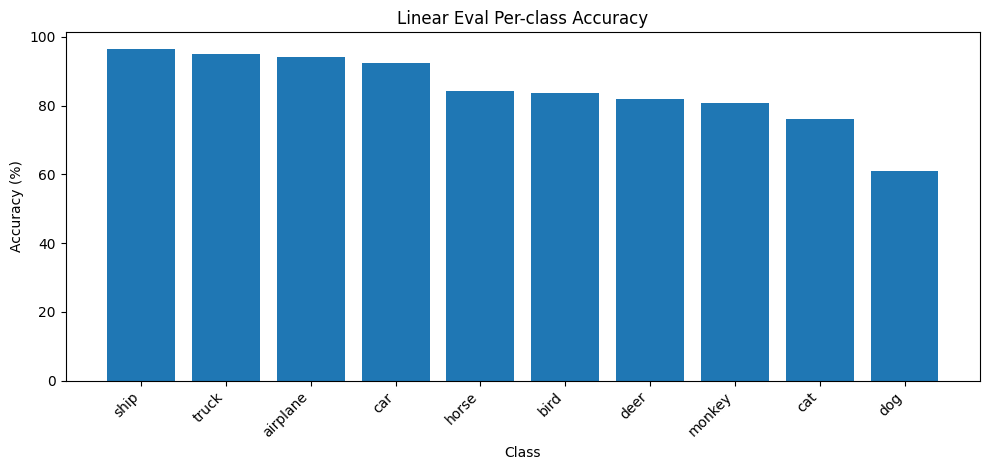

In [11]:
cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
for t, p in zip(best_eval["y_true"], best_eval["y_pred"]):
    cm[int(t), int(p)] += 1

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title(f"Linear Eval Confusion Matrix | Acc={best_eval['acc']:.2f}%")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar()
plt.tight_layout()
save_fig("linear_eval_confusion_matrix")
plt.show()

cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 7))
plt.imshow(cm_norm)
plt.title("Linear Eval Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar()
plt.tight_layout()
save_fig("linear_eval_confusion_matrix_normalized")
plt.show()

df_class = pd.DataFrame({
    "class": class_names,
    "correct": np.diag(cm),
    "total": cm.sum(axis=1),
})
df_class["accuracy"] = df_class["correct"] / df_class["total"].clip(lower=1)
df_class = df_class.sort_values("accuracy", ascending=False)

display(df_class)
df_class.to_csv(TABLE_DIR / "linear_eval_per_class_accuracy.csv", index=False)

plt.figure(figsize=(10, 4.8))
plt.bar(df_class["class"], df_class["accuracy"] * 100)
plt.title("Linear Eval Per-class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig("linear_eval_per_class_accuracy")
plt.show()


## 11. Confidence and summary


Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_confidence_histogram.png
Saved: D:\ML3\paper_outputs\linear_eval_memorysafe\figures\linear_eval_confidence_histogram.pdf


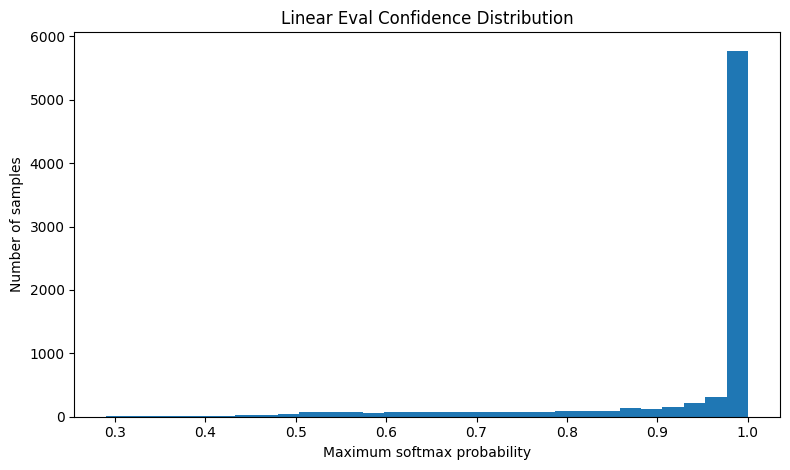

,method,backbone,pretrain_checkpoint,best_epoch,best_val_acc,val_loss,correct,total,lr,weight_decay
0,SimCLRv2 Linear Evaluation,resnet50,simclrv2_resnet50_epoch_300.pt,24,84.55,0.654684,6764,8000,0.1,0.0


Figures: D:\ML3\paper_outputs\linear_eval_memorysafe\figures
Tables: D:\ML3\paper_outputs\linear_eval_memorysafe\tables


In [12]:
conf = best_eval["y_prob"].max(axis=1)
correct_mask = best_eval["y_true"] == best_eval["y_pred"]

df_pred = pd.DataFrame({
    "y_true": best_eval["y_true"],
    "y_pred": best_eval["y_pred"],
    "true_class": [class_names[i] for i in best_eval["y_true"]],
    "pred_class": [class_names[i] for i in best_eval["y_pred"]],
    "confidence": conf,
    "correct": correct_mask,
})
df_pred.to_csv(TABLE_DIR / "linear_eval_predictions.csv", index=False)

plt.figure(figsize=(8, 4.8))
plt.hist(df_pred["confidence"], bins=30)
plt.title("Linear Eval Confidence Distribution")
plt.xlabel("Maximum softmax probability")
plt.ylabel("Number of samples")
plt.tight_layout()
save_fig("linear_eval_confidence_histogram")
plt.show()

summary = pd.DataFrame([{
    "method": "SimCLRv2 Linear Evaluation",
    "backbone": ARCH,
    "pretrain_checkpoint": PRETRAIN_CKPT.name,
    "best_epoch": best_payload["epoch"],
    "best_val_acc": best_eval["acc"],
    "val_loss": best_eval["loss"],
    "correct": best_eval["correct"],
    "total": best_eval["total"],
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
}])
summary.to_csv(TABLE_DIR / "linear_eval_summary.csv", index=False)
display(summary)

print("Figures:", FIG_DIR)
print("Tables:", TABLE_DIR)
